# T49 — Cooling rates × plate kinematics × fault analysis

**Cluster F: paleo-geography and paleo-topography.**

*Based on:* Boone et al. (2025), *Communications Earth & Environment* 6, 1015. *Deciphering mantle, tectonic and climatic drivers of exhumation* — specifically the **plate-kinematics + fault-proximity** stages of the upstream ThermoPlates `03_Thermochron_GPlates.sh` script (plus the per-age summary plots of `04_Kinematics.sh`).

## What this notebook does

Where **T47** drops Central Asian thermochronology cooling rates on a paleo-Earth, and **T48** layers them on Earth-system rasters (seafloor age, paleotopography), this notebook brings in the **tectonic** context: the convergence-rate field along subduction zones, the trench-migration field, the orientation of plate motion / arcs / convergence, and the **proximity of fast-cooling samples to active faults**. Boone et al. (2025)'s key result for Central Asia was that exhumation was driven primarily by reactivation of pre-Mesozoic crustal-scale shear zones in response to Tethyan subduction kinematics — exactly the link this notebook surfaces.

**Sections (mapped to upstream scripts):**
1. **§4** — Subduction kinematics via `gplately.PlateReconstruction.tessellate_subduction_zones()`, cookie-cut to Boone's per-age `Southern_Margin_Polygons_V4` polygon (script 03's `eurasia` mask).
2. **§5** — Cooling rates × convergence rate, global orthographic + Eurasian-margin Albers zoom (script 03's `cooling_convergence_rates_*` figures).
3. **§6** — Cooling rates × trench migration rate, Eurasian zoom (script 03's `cooling_trench_migration_*` figures).
4. **§7** — **Fault-proximity analysis** — which GEM + AFEAD faults sit within 25 km of fast-cooling samples? (script 03's `faults_near_cooling_*` figures.)
5. **§8** — **Rose diagrams** of plate-velocity azimuth, convergence azimuth, and fault azimuth in the cooling region (script 03's `rose_*` figures).
6. **§9** — Output a per-age `kinematics_master.parquet` table — the equivalent of Boone's `kinematics_master.xyz` — for downstream joins with T50.

**Audience**: postgrad → researcher.
**Difficulty**: ★★★.
**Runtime**: ~3 min for a single snapshot (kinematics extraction + fault proximity + rose diagrams). Looping multiple snapshots is in *Extend this*.

## Data availability

Bundled inputs (under `data/thermochronology/`):
- `Southern_Margin_Polygons_V4/reconstructed_{age:.2f}Ma.xy` — Boone's per-age Eurasian-margin polygon, 1-Myr cadence 0–230 Ma. Small (≈700 bytes each, 231 files).
- `Faults/reconstructed_{age:.2f}Ma.gmt` — GEM Global Active Faults Database, pre-reconstructed by Boone using Zahirovic 2022 plate motions. 1-Myr cadence; ~1.8 MB per file.
- `AFEAD_Faults/AFEAD_v2022/reconstructed_{age:.2f}Ma.gmt` — Active Faults of Eurasia Database (regional supplement), pre-reconstructed.

Plus the ThermoPlates compilation already bundled at `data/thermochronology_central_asia/central_asia_thermal_histories.csv` (used by T47/T48/T50).

**One thing this notebook does NOT need:** Boone's `Kinematics/SubductionVolumesAreaTable_clean_0_230Ma_4.csv`. The same per-segment subduction-kinematics quantities (convergence rate, conv obliquity, trench migration, migr obliquity, arc length, arc azimuth) are computed live via `gplately.PlateReconstruction.tessellate_subduction_zones()` — same plate model, same algorithm family, no static CSV bundle required.

## Source
- Upstream shell scripts: https://github.com/samuelcboone/ThermoPlates (scripts `03_Thermochron_GPlates.sh` for the maps + fault proximity + rose diagrams; `04_Kinematics.sh` for the kinematics-vs-age time-series).
- Boone et al. (2025) DOI: https://doi.org/10.1038/s43247-025-03005-6.

## Environment + imports

In [1]:
from pathlib import Path
import os, sys, math, warnings
if Path("../data").exists() and not Path("data").exists():
    os.chdir("..")

import numpy as np
import pandas as pd
import xarray as xr

import shapely
from shapely.geometry import Polygon, Point, LineString, MultiLineString
from shapely.ops import unary_union
from sklearn.neighbors import BallTree

import matplotlib.pyplot as plt
import gplately
import pygmt
from plate_model_manager import PlateModelManager

print("Environment")
print(f"  python      {sys.version.split()[0]}")
for _m in (np, pd, shapely, gplately, pygmt):
    print(f"  {_m.__name__:11s} {getattr(_m, '__version__', 'n/a')}")

Environment
  python      3.12.5
  numpy       2.3.2
  pandas      2.2.3
  shapely     2.1.1
  gplately    2.0.0.post19+git.2cce7bb3
  pygmt       v0.18.0


In [2]:
# === USER CONFIGURATION =====================================================
# Plate model + reference frame. Z22 mantle frame — same setup as Boone.
MODEL_NAME             = "Zahirovic2022"
ANCHOR_PLATE_ID        = 0
RECONSTRUCTION_TIME    = 100.0

# Inputs.
HISTORIES_CSV          = Path("data/thermochronology_central_asia/central_asia_thermal_histories.csv")
EURASIA_POLYGON_DIR    = Path("data/thermochronology/Southern_Margin_Polygons_V4")
GEM_FAULTS_DIR         = Path("data/thermochronology/Faults")
AFEAD_FAULTS_DIR       = Path("data/thermochronology/AFEAD_Faults/AFEAD_v2022")

# Boone's cooling-rate classification (°C/Myr) — see T47 + the ThermoPlates 02 script.
FAST_CR                = 0.5       # `fast`
VERY_FAST_CR           = 1.0       # `very fast`
EXTRA_FAST_CR          = 1.5       # `extra fast` — the cut-off Boone uses for fault proximity
CUTOFF_CR              = VERY_FAST_CR    # >= this rate = the fault-proximity test set

# Fault-proximity radius — Boone 03_Thermochron_GPlates.sh uses 25 km (`+d25k`).
FAULT_PROXIMITY_KM     = 25.0

# Region for the Eurasian-margin zoom (matches Boone's Albers panel R=20/120/0/70).
REGION_EURASIA         = [20, 120, 0, 70]
EURASIA_PROJ           = "B70/35/15/55/16c"   # Albers conic, centre 70°E 35°N, secants 15°/55°
GLOBAL_PROJ            = "G73/37/16c"          # orthographic, Boone's choice

# Subduction-kinematics tessellation density (radians along trench).
# 0.005 rad ~ 32 km segments at Earth radius — fine enough for regional analysis.
TESS_THRESHOLD_RAD     = 0.005

# Output parquet for downstream T50 / co-analysis.
KINEMATICS_MASTER_DIR  = Path("data/thermochronology_central_asia/kinematics_master")
KINEMATICS_MASTER_DIR.mkdir(parents=True, exist_ok=True)
# ============================================================================

## 1. Load plate model, sample compilation, polygon, and faults

In [3]:
pmm = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")
recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons(),
    anchor_plate_id=ANCHOR_PLATE_ID,
)
gplot = gplately.PlotTopologies(
    plate_reconstruction=recon,
    coastlines=model.get_coastlines(),
    continents=model.get_continental_polygons(),
    COBs=model.get_COBs(),
    time=float(RECONSTRUCTION_TIME),
    plot_engine=gplately.PygmtPlotEngine(),
)

hist = pd.read_csv(HISTORIES_CSV, comment="#")
print(f"  thermal histories: {len(hist):,} rows, {hist['sample_name'].nunique()} samples")

  thermal histories: 23,119 rows, 377 samples


In [4]:
def load_eurasia_polygon(age_ma: float) -> Polygon:
    """Read Boone's per-age Southern_Margin_Polygons_V4 .xy file as a shapely
    polygon. GPlates .xy format has '>' header lines followed by lon/lat rows."""
    fp = EURASIA_POLYGON_DIR / f"reconstructed_{age_ma:.2f}Ma.xy"
    if not fp.exists():
        raise FileNotFoundError(f"polygon not found: {fp}")
    coords = []
    for line in fp.read_text().splitlines():
        line = line.strip()
        if not line or line.startswith(">"):
            continue
        parts = line.split()
        if len(parts) >= 2:
            coords.append((float(parts[0]), float(parts[1])))
    if len(coords) < 3:
        raise ValueError(f"polygon at {age_ma:.0f} Ma has only {len(coords)} vertices")
    return Polygon(coords)

eurasia = load_eurasia_polygon(RECONSTRUCTION_TIME)
print(f"  Southern_Margin polygon at {RECONSTRUCTION_TIME:.0f} Ma: "
      f"{len(list(eurasia.exterior.coords))-1} vertices, bbox = {eurasia.bounds}")

  Southern_Margin polygon at 100 Ma: 6 vertices, bbox = (35.584439, 10.257214, 86.167542, 28.090742)


In [5]:
def load_faults_gmt(fp: Path) -> list[LineString]:
    """Parse a Boone-reconstructed GMT fault file (OGR-GMT format with '>' as
    feature separators and '#'-prefixed metadata lines) into a list of shapely
    LineStrings."""
    if not fp.exists():
        raise FileNotFoundError(fp)
    lines = []
    current = []
    for raw in fp.read_text().splitlines():
        s = raw.strip()
        if not s or s.startswith("#"):
            continue
        if s.startswith(">"):
            if len(current) >= 2:
                lines.append(LineString(current))
            current = []
            continue
        parts = s.split()
        if len(parts) >= 2:
            try:
                current.append((float(parts[0]), float(parts[1])))
            except ValueError:
                pass
    if len(current) >= 2:
        lines.append(LineString(current))
    return lines

gem_faults    = load_faults_gmt(GEM_FAULTS_DIR    / f"reconstructed_{RECONSTRUCTION_TIME:.2f}Ma.gmt")
afead_faults  = load_faults_gmt(AFEAD_FAULTS_DIR  / f"reconstructed_{RECONSTRUCTION_TIME:.2f}Ma.gmt")
print(f"  GEM faults at {RECONSTRUCTION_TIME:.0f} Ma:   {len(gem_faults):,} segments")
print(f"  AFEAD faults at {RECONSTRUCTION_TIME:.0f} Ma: {len(afead_faults):,} segments")

  GEM faults at 100 Ma:   4,553 segments
  AFEAD faults at 100 Ma: 45,591 segments


## 2. Per-sample cooling rate + reconstruction (same helper as T48/T50)

In [6]:
def per_sample_cooling_at(age_ma: float, hist_df: pd.DataFrame) -> pd.DataFrame:
    """Boone's pre-computed TempDiff column = per-sample, per-window cooling
    rate (°C/Myr) at age_ma. See T48/T50 for the OnlyCooling pitfall."""
    snap = hist_df.loc[hist_df["TOAGE"] == int(age_ma)].copy()
    snap["cooling_rate"] = pd.to_numeric(snap["TempDiff"], errors="coerce")
    snap = snap.dropna(subset=["cooling_rate", "lat", "lon"])
    snap["cooling_rate"] = snap["cooling_rate"].clip(lower=0)
    return (snap.groupby("sample_name", as_index=False)
                .agg(lat=("lat","first"), lon=("lon","first"),
                     cooling_rate=("cooling_rate","mean")))

samples = per_sample_cooling_at(RECONSTRUCTION_TIME, hist)
print(f"  {len(samples)} samples at {RECONSTRUCTION_TIME:.0f} Ma; "
      f"cooling-rate range {samples.cooling_rate.min():.2f} – "
      f"{samples.cooling_rate.max():.2f} °C/Myr")

# Reconstruct to paleo-position
gpts = gplately.Points(recon, samples["lon"].to_numpy(float),
                              samples["lat"].to_numpy(float),
                              anchor_plate_id=ANCHOR_PLATE_ID)
rlons, rlats = gpts.reconstruct(RECONSTRUCTION_TIME,
                                  return_array=True,
                                  anchor_plate_id=ANCHOR_PLATE_ID)
samples = samples.assign(rlon=rlons, rlat=rlats).dropna(subset=["rlon","rlat"]).copy()

fast_samples = samples[samples.cooling_rate >= CUTOFF_CR].copy()
print(f"  {len(fast_samples)} of {len(samples)} samples are fast-cooling "
      f"(>= {CUTOFF_CR:.1f} °C/Myr) — these drive the fault-proximity test.")

  286 samples at 100 Ma; cooling-rate range 0.00 – 5.44 °C/Myr
  58 of 286 samples are fast-cooling (>= 1.0 °C/Myr) — these drive the fault-proximity test.


## 3. Subduction kinematics via GPlately

`PlateReconstruction.tessellate_subduction_zones(time)` walks every plate-boundary
subduction segment and returns one row per ~5–30 km along-trench point with the
kinematic quantities Boone et al. (2025) parse from their pre-computed CSV: lon,
lat, convergence rate (cm/yr), convergence obliquity (°), trench migration
rate, migration obliquity, segment length, and arc-normal azimuth. We then
cookie-cut to Boone's `Southern_Margin_Polygons_V4` polygon to isolate the
Eurasian-margin subset that's most relevant to Central Asian cooling.

In [7]:
kin = recon.tessellate_subduction_zones(
    float(RECONSTRUCTION_TIME),
    tessellation_threshold_radians=TESS_THRESHOLD_RAD,
    anchor_plate_id=ANCHOR_PLATE_ID,
)
kin_df = pd.DataFrame(kin, columns=[
    "lon", "lat", "conv_rate_cm_yr", "conv_obliquity_deg",
    "migr_rate_cm_yr", "migr_obliquity_deg",
    "segment_length_rad", "arc_normal_azimuth_deg",
    "subducting_plate_id", "overriding_plate_id",
])
print(f"  global subduction segments at {RECONSTRUCTION_TIME:.0f} Ma: {len(kin_df):,}")

# Cookie-cut to the Eurasian polygon (Boone's `gmt select -F$eurasia`).
from shapely.vectorized import contains
inside = contains(eurasia, kin_df["lon"].to_numpy(), kin_df["lat"].to_numpy())
kin_eu = kin_df.loc[inside].copy()
print(f"  subset inside Southern_Margin polygon: {len(kin_eu):,}")

# Per-polygon summary statistics — these become rows of kinematics_master.parquet later.
summary = {
    "age_Ma":                   float(RECONSTRUCTION_TIME),
    "n_segments_eurasia":       int(len(kin_eu)),
    "mean_conv_rate_cm_yr":     float(kin_eu["conv_rate_cm_yr"].mean()),
    "std_conv_rate_cm_yr":      float(kin_eu["conv_rate_cm_yr"].std()),
    "mean_migr_rate_cm_yr":     float(kin_eu["migr_rate_cm_yr"].mean()),
    "std_migr_rate_cm_yr":      float(kin_eu["migr_rate_cm_yr"].std()),
    "mean_arc_azimuth_deg":     float(kin_eu["arc_normal_azimuth_deg"].mean()),
}
pd.Series(summary).round(2)

  global subduction segments at 100 Ma: 2,183
  subset inside Southern_Margin polygon: 142


/Users/dietmar/tmp/ipykernel_26679/245754074.py:16: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).


age_Ma                  100.00
n_segments_eurasia      142.00
mean_conv_rate_cm_yr      2.40
std_conv_rate_cm_yr       1.65
mean_migr_rate_cm_yr      1.04
std_migr_rate_cm_yr       3.51
mean_arc_azimuth_deg     66.50
dtype: float64

## 4. §5 — Cooling rates × convergence rate (Eurasian-margin Albers zoom)

Boone et al. (2025)'s `cooling_convergence_rates_eurasia_${age}.ps` figure.
Cooling-rate dots (viridis) sit on top of convergence-rate dots (vik
diverging palette) along the Eurasian subduction margin; the polygon
outline is drawn so the cookie-cut footprint is visible.

Boone et al. (2025) use this figure pair to test the *first-order* tectonic
driver hypothesis: where the southern Eurasian active margin was experiencing
fast (>5 cm/yr) orthogonal convergence, the overriding plate should be storing
compressive stress that propagates inboard along inherited crustal-scale shear
zones, driving exhumation of the Central Asian samples we see cooling rapidly.
Visually, the test is: do the brightest cooling-rate dots (yellow viridis) sit
in the same Albers panel as the most intensely red (high-convergence) margin
segments? Their abstract conclusion is that yes — plate kinematics, not
mantle-flow uplift, was the dominant control on Central Asian Mesozoic-to-
recent exhumation.

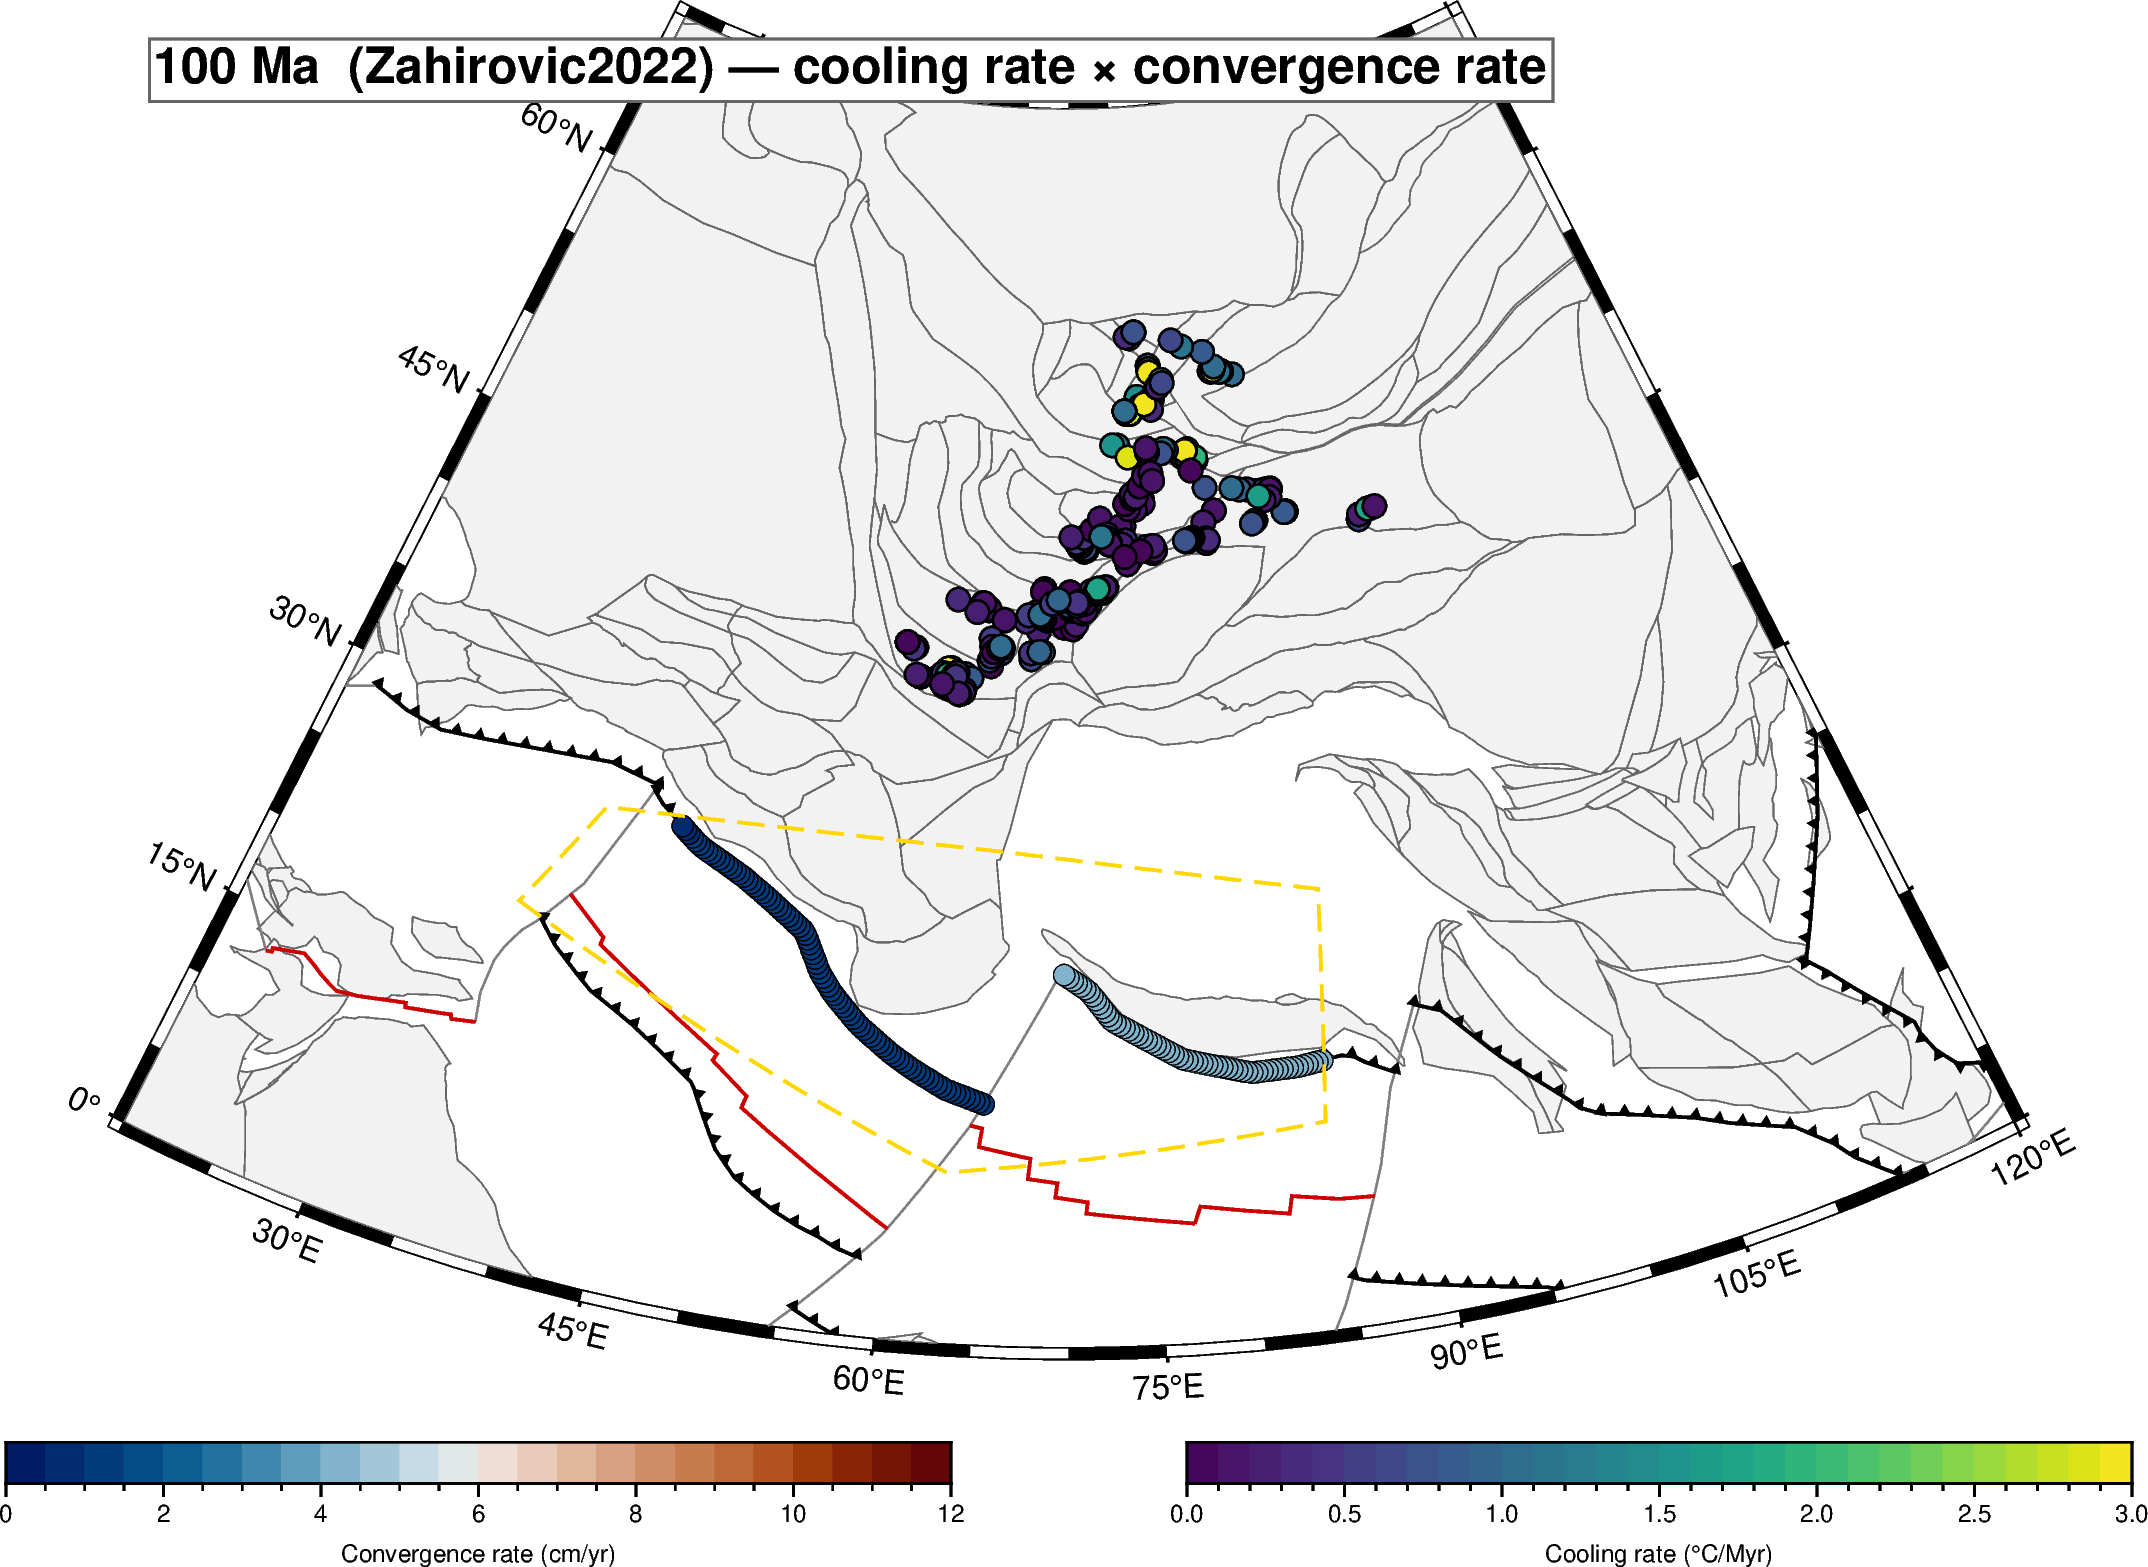

In [8]:
def add_eurasia_polygon(fig, polygon: Polygon, pen="0.8p,gold,dashed"):
    """Plot polygon outline on a pyGMT figure."""
    lons, lats = zip(*polygon.exterior.coords)
    fig.plot(x=list(lons), y=list(lats), pen=pen)

fig = pygmt.Figure()
fig.basemap(region=REGION_EURASIA, projection=EURASIA_PROJ, frame=["af", "WSne"])

# Base: plate boundaries + subduction teeth (in-region)
gplot.time = float(RECONSTRUCTION_TIME)
gplot.plot_continents(fig, fill="gray95", pen="0.3p,gray40")
gplot.plot_all_topological_sections(fig, pen="0.5p,gray50")
gplot.plot_ridges(fig, pen="0.8p,red3")
gplot.plot_trenches(fig, pen="0.8p,black")
gplot.plot_subduction_teeth(fig, color="black")

# Convergence-rate dots (Eurasian subset only)
pygmt.makecpt(cmap="vik", series=[0, 12, 0.5], background="o")
fig.plot(x=kin_eu["lon"], y=kin_eu["lat"],
         fill=kin_eu["conv_rate_cm_yr"], cmap=True,
         style="c0.18c", pen="0.2p,black")
fig.colorbar(cmap=True, position="JBC+w8c/0.35c+h+o-5c/0.8c",
             frame=["xa2f0.5+lConvergence rate (cm/yr)"])

# Polygon outline
add_eurasia_polygon(fig, eurasia)

# Cooling-rate dots on top
pygmt.makecpt(cmap="viridis", series=[0, 3, 0.1], background="o")
fig.plot(x=samples["rlon"], y=samples["rlat"],
         fill=samples["cooling_rate"], cmap=True,
         style="c0.20c", pen="0.5p,black")
fig.colorbar(cmap=True, position="JBC+w8c/0.35c+h+o5c/0.8c",
             frame=["xa0.5f0.1+lCooling rate (@.C/Myr)"])

# Title stamp
fig.text(text=f"{RECONSTRUCTION_TIME:.0f} Ma  ({MODEL_NAME}) — cooling rate \u00d7 convergence rate",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="12p,Helvetica-Bold,black", fill="white", pen="0.6p,gray40")
fig.show(width=900)

## 5. §6 — Cooling rates × trench migration rate

Same Eurasian-margin frame, but the kinematic colour scale now codes
**trench migration rate** (script 03's `cooling_trench_migration_eurasia_${age}.ps`).
Positive = trench retreating (oceanward); negative = trench advancing
(towards overriding plate). Boone uses a no_green diverging palette here
centred at zero; pyGMT's `polar` is the closest built-in equivalent.

Where convergence rate measures *how fast* the two plates are colliding,
trench migration rate measures *which way the boundary itself is moving in the
mantle frame*. Boone et al. (2025) distinguish between **advancing** trenches
(negative, blue — trench moving towards the overriding plate, causing
compressional shortening and exhumation in the back-arc) and **retreating**
trenches (positive, red — trench moving oceanward, causing back-arc
extension). The Tethyan margin alternates between these regimes through the
Mesozoic-Cenozoic; the figure surfaces the spatial coincidence between trench-
migration phases and cooling pulses in adjacent continental interiors. T50
(downstream) quantifies the correlation systematically across the whole
230-0 Ma window once DT data is available.

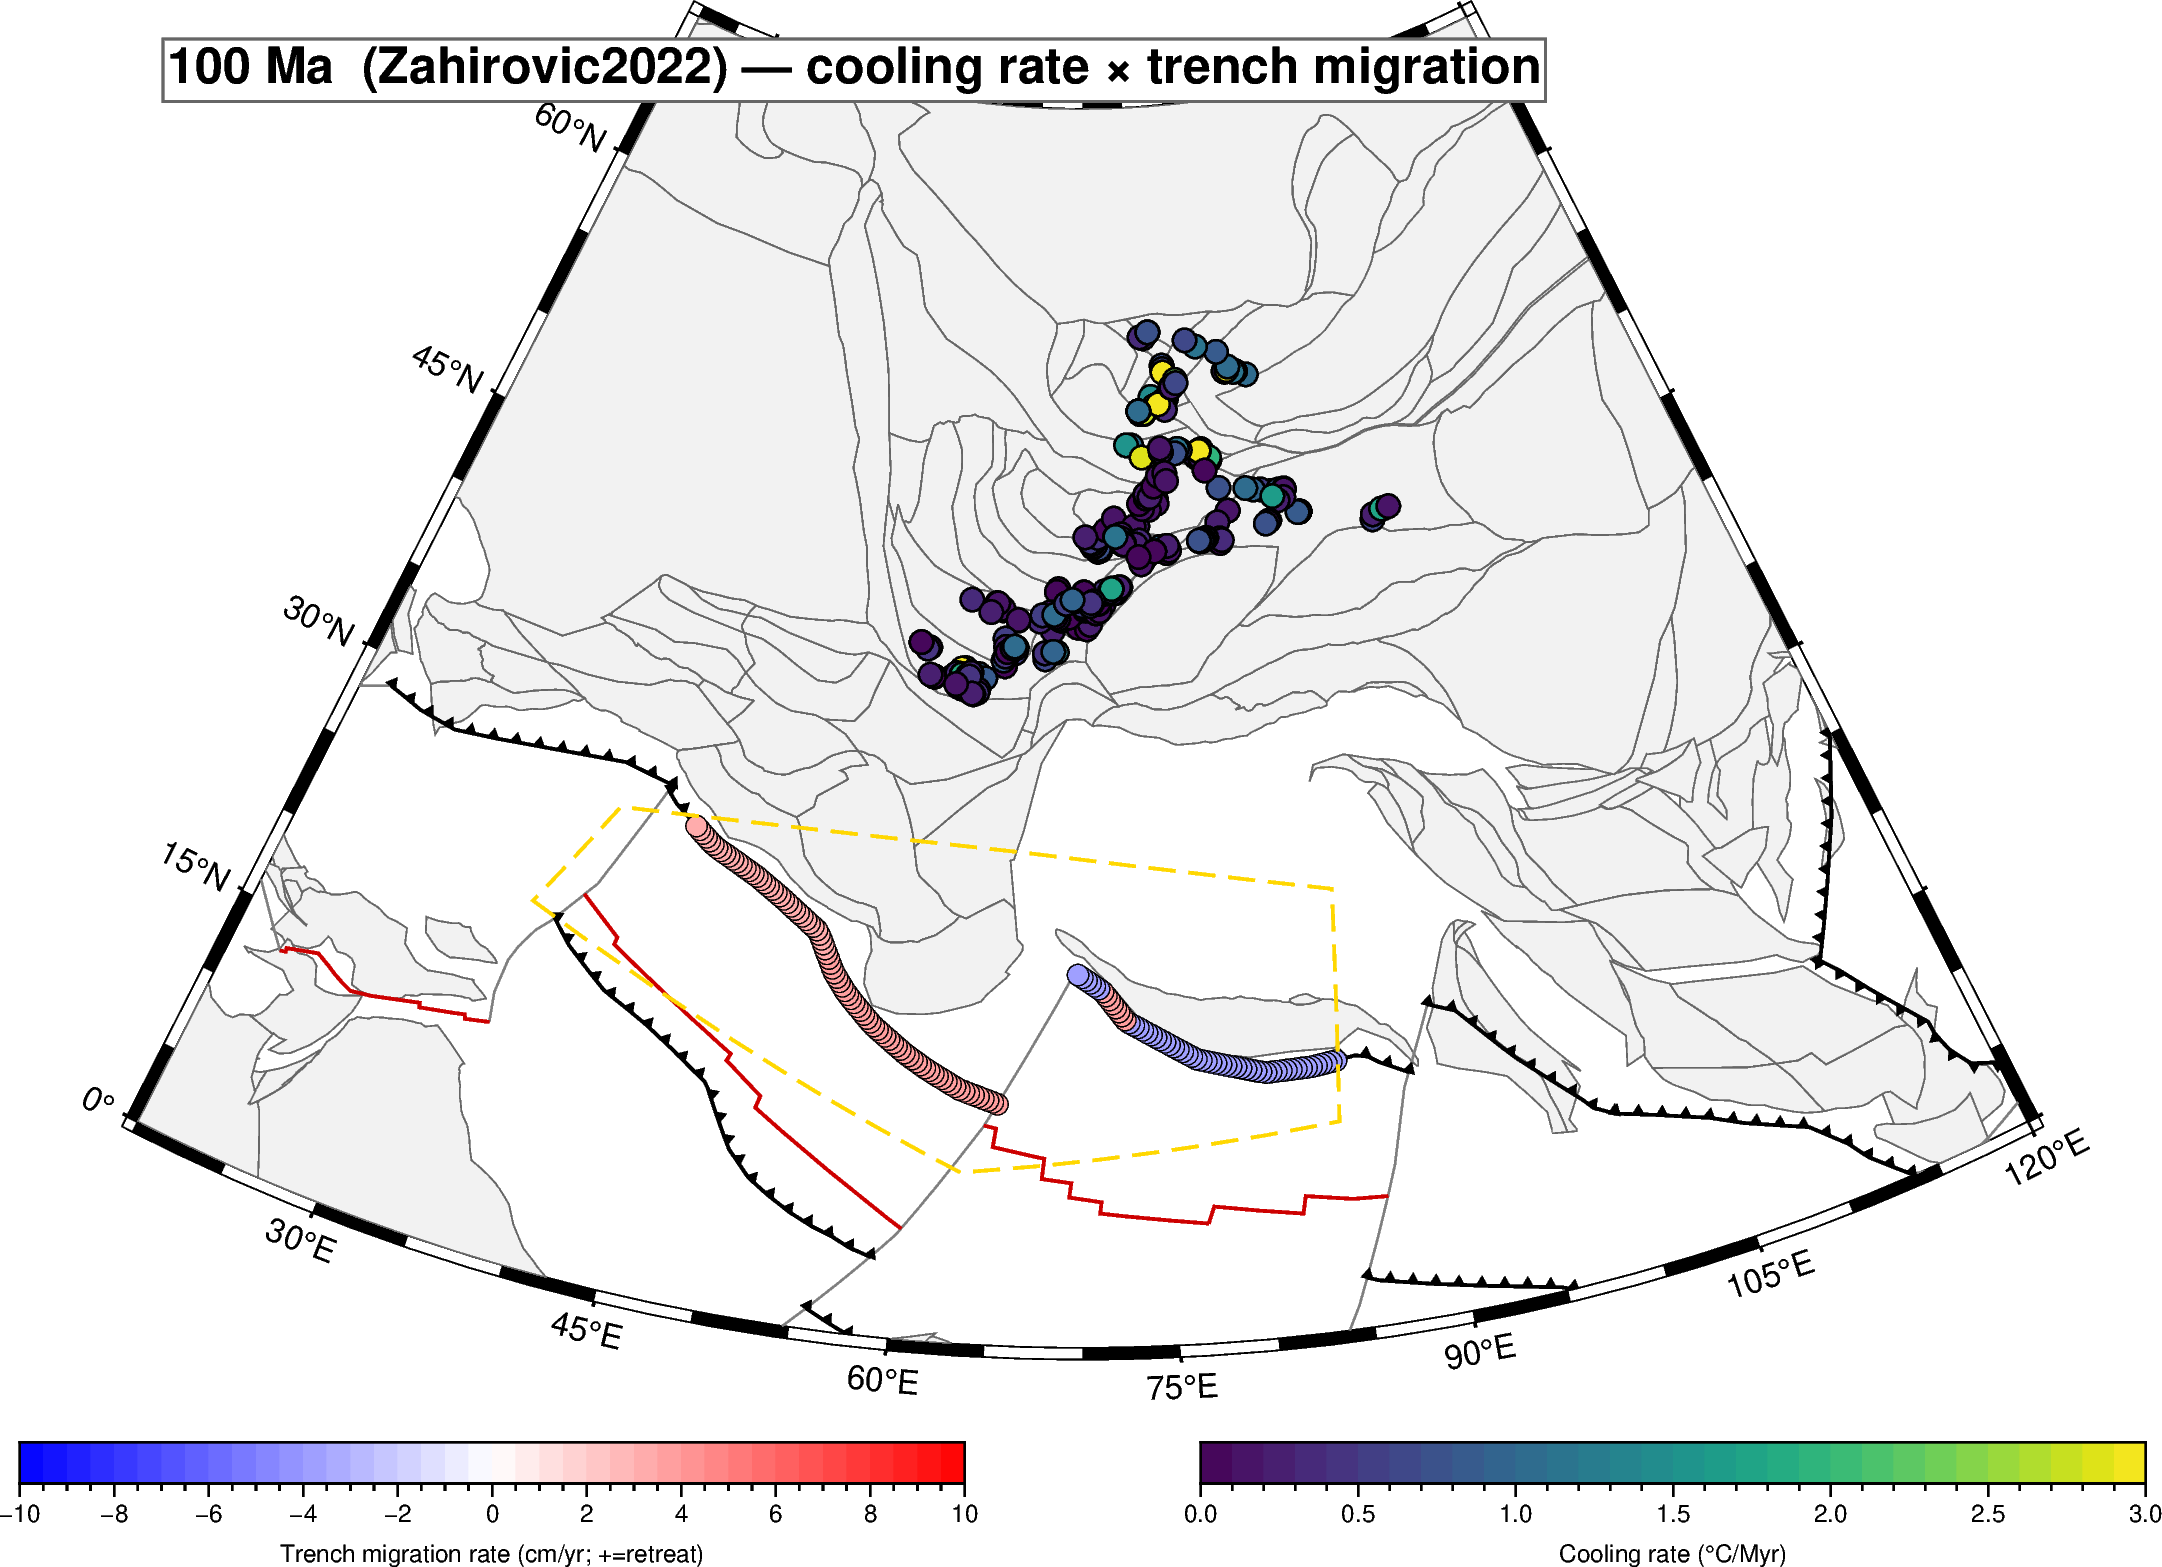

In [9]:
fig = pygmt.Figure()
fig.basemap(region=REGION_EURASIA, projection=EURASIA_PROJ, frame=["af", "WSne"])

gplot.time = float(RECONSTRUCTION_TIME)
gplot.plot_continents(fig, fill="gray95", pen="0.3p,gray40")
gplot.plot_all_topological_sections(fig, pen="0.5p,gray50")
gplot.plot_ridges(fig, pen="0.8p,red3")
gplot.plot_trenches(fig, pen="0.8p,black")
gplot.plot_subduction_teeth(fig, color="black")

pygmt.makecpt(cmap="polar", series=[-10, 10, 0.5], background="o")
fig.plot(x=kin_eu["lon"], y=kin_eu["lat"],
         fill=kin_eu["migr_rate_cm_yr"], cmap=True,
         style="c0.18c", pen="0.2p,black")
fig.colorbar(cmap=True, position="JBC+w8c/0.35c+h+o-5c/0.8c",
             frame=["xa2f0.5+lTrench migration rate (cm/yr; +=retreat)"])

add_eurasia_polygon(fig, eurasia)

pygmt.makecpt(cmap="viridis", series=[0, 3, 0.1], background="o")
fig.plot(x=samples["rlon"], y=samples["rlat"],
         fill=samples["cooling_rate"], cmap=True,
         style="c0.20c", pen="0.5p,black")
fig.colorbar(cmap=True, position="JBC+w8c/0.35c+h+o5c/0.8c",
             frame=["xa0.5f0.1+lCooling rate (@.C/Myr)"])

fig.text(text=f"{RECONSTRUCTION_TIME:.0f} Ma  ({MODEL_NAME}) — cooling rate \u00d7 trench migration",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="12p,Helvetica-Bold,black", fill="white", pen="0.6p,gray40")
fig.show(width=900)

## 6. §7 — Fault proximity

Boone's `03_Thermochron_GPlates.sh` extracts faults from the GEM + AFEAD
databases that pass within **25 km** of any fast-cooling sample at the snapshot
age. The argument is that those faults are the most plausible candidates for
*driving* the cooling pulse — exhumation along reactivated crustal-scale shear
zones. We replicate the test with a haversine BallTree query, then render the
result: all faults in light grey, active-near-fast-cooling faults in red,
fast-cooling samples coloured by rate on top.

Of all the figures in Boone et al. (2025), this is the one that most directly
advances the paper's main scientific argument. The hypothesis: continental
exhumation is mechanically transmitted from the active subduction margin to
the interior via **reactivation of pre-existing crustal-scale faults**. If
true, the faults that sit within 25 km of any fast-cooling sample (red and
orange overlays) should be over-represented among the longest, most
favourably-oriented faults in the GEM/AFEAD catalogues. Boone et al. (2025)
show that for Central Asia this is exactly what happens: the reactivated set
is dominated by the major Cenozoic and pre-Mesozoic Tian Shan / Altai / Sayan
shear zones — not by random faults. Note that the 25 km radius is Boone's
convention (`+d25k` in script 03); sensitivity to that radius is a useful
*Extend this* experiment.

In [10]:
EARTH_RADIUS_KM = 6371.0

def faults_within_radius(faults: list, fast_lons: np.ndarray, fast_lats: np.ndarray,
                          radius_km: float):
    """Return the subset of `faults` (list of shapely LineStrings) that have at
    least one vertex within `radius_km` of any (fast_lons, fast_lats) point.
    Uses a haversine BallTree on the fast-cooling points."""
    if len(faults) == 0 or len(fast_lons) == 0:
        return []
    fast_rad = np.radians(np.column_stack([fast_lats, fast_lons]))
    tree     = BallTree(fast_rad, metric="haversine")
    radius_rad = radius_km / EARTH_RADIUS_KM
    active = []
    for fl in faults:
        node_arr = np.array(fl.coords)              # (n, 2) lon, lat
        if node_arr.size == 0:
            continue
        node_rad = np.radians(np.column_stack([node_arr[:, 1], node_arr[:, 0]]))
        # Any node within radius?
        ind, _ = tree.query_radius(node_rad, r=radius_rad, return_distance=True)
        if any(len(x) > 0 for x in ind):
            active.append(fl)
    return active

gem_active   = faults_within_radius(gem_faults,   fast_samples["rlon"].values,
                                                   fast_samples["rlat"].values,
                                                   FAULT_PROXIMITY_KM)
afead_active = faults_within_radius(afead_faults, fast_samples["rlon"].values,
                                                   fast_samples["rlat"].values,
                                                   FAULT_PROXIMITY_KM)
print(f"  GEM active (within {FAULT_PROXIMITY_KM:.0f} km of fast-cooling samples): "
      f"{len(gem_active):,} of {len(gem_faults):,}")
print(f"  AFEAD active: {len(afead_active):,} of {len(afead_faults):,}")

  GEM active (within 25 km of fast-cooling samples): 21 of 4,553
  AFEAD active: 140 of 45,591


In [11]:
def faults_to_xy(fault_list):
    """Concatenate shapely LineStrings into a single (x, y) array with NaN
    separators, ready for one pyGMT `fig.plot(...)` call."""
    if len(fault_list) == 0:
        return np.empty(0), np.empty(0)
    xs, ys = [], []
    for fl in fault_list:
        for x, y in fl.coords:
            xs.append(x); ys.append(y)
        xs.append(np.nan); ys.append(np.nan)
    return np.array(xs), np.array(ys)

fig = pygmt.Figure()
fig.basemap(region=REGION_EURASIA, projection=EURASIA_PROJ, frame=["af", "WSne"])
gplot.time = float(RECONSTRUCTION_TIME)
gplot.plot_continents(fig, fill="gray95", pen="0.3p,gray40")
gplot.plot_all_topological_sections(fig, pen="0.4p,gray60")
gplot.plot_trenches(fig, pen="0.6p,black")
gplot.plot_subduction_teeth(fig, color="black")

# Background faults (light grey)
gx, gy = faults_to_xy(gem_faults)
if gx.size: fig.plot(x=gx, y=gy, pen="0.15p,gray70")
ax_, ay_ = faults_to_xy(afead_faults)
if ax_.size: fig.plot(x=ax_, y=ay_, pen="0.15p,gray80")

# Active faults (red)
agx, agy = faults_to_xy(gem_active)
if agx.size: fig.plot(x=agx, y=agy, pen="0.6p,firebrick")
aax, aay = faults_to_xy(afead_active)
if aax.size: fig.plot(x=aax, y=aay, pen="0.6p,orange3")

# Fast-cooling samples on top
pygmt.makecpt(cmap="viridis", series=[CUTOFF_CR, 3, 0.1], background="o")
fig.plot(x=fast_samples["rlon"], y=fast_samples["rlat"],
         fill=fast_samples["cooling_rate"], cmap=True,
         style="c0.22c", pen="0.5p,black")
fig.colorbar(cmap=True, position="JBC+w8c/0.35c+h+o0c/0.8c",
             frame=[f"xa0.5f0.1+lFast-cooling rate (>{CUTOFF_CR:.1f} @.C/Myr)"])
fig.text(text=f"{RECONSTRUCTION_TIME:.0f} Ma — GEM (firebrick) + AFEAD (orange) faults within "
              f"{FAULT_PROXIMITY_KM:.0f} km of fast-cooling samples",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="11p,Helvetica-Bold,black", fill="white", pen="0.6p,gray40")
fig.show(width=900)

plot [WARNING]: Your data array row 3 contains NaNs - no resampling taken place!
plot [WARNING]: Your data array row 22 contains NaNs - no resampling taken place!
plot [WARNING]: Your data array row 10 contains NaNs - no resampling taken place!
plot [WARNING]: Your data array row 9 contains NaNs - no resampling taken place!


## 7. §8 — Rose diagrams

Boone's `03_Thermochron_GPlates.sh` produces a family of rose diagrams that
summarise the orientation distributions in the Eurasian-margin window:
convergence azimuth, trench-migration azimuth, arc azimuth, plate-velocity
azimuth, and the fault azimuths (USGS + AFEAD). Here we show three of those
— convergence azimuth (along-trench mean), fault azimuth (the active-fault
subset from §7), and plate-velocity azimuth at sample locations.

Rendered via `matplotlib`'s polar projection; bins span 0–360° in 10°
steps. Conv azimuth uses `arc_normal_azimuth + conv_obliquity` per Boone's
formula.

Three orientation distributions tell three different stories:

1. **Convergence azimuth** — the direction in which the subducting plate
   is converging onto Eurasia, summarised over all in-polygon segments. This is
   the *driving* stress orientation transmitted inboard.

2. **Active-fault strike** — the *bidirectional* (180°-folded) strike
   distribution of the faults flagged active in §6. If this distribution is
   peaked roughly perpendicular to the convergence azimuth, the faults are
   *favourably oriented for thrust reactivation* under the modern stress field;
   peaked parallel implies strike-slip reactivation; oblique implies neither.

3. **Plate-velocity azimuth** — the direction the *Eurasian plate itself*
   is moving in the mantle frame at each fast-cooling sample location. Tells
   us whether the upper-plate motion is consistent with the convergence vector,
   or whether absolute plate motion contributes its own stress component.

Boone et al. (2025) use these jointly to demonstrate that the active Central
Asian faults are roughly orthogonal to Tethyan convergence — the
mechanically natural orientation for thrust-style reactivation.

In [12]:
def line_azimuth_deg(fl: LineString) -> float:
    """Azimuth of the great-circle chord from the line's first to last vertex,
    in 0–360° from north. Approximate but consistent with Boone's
    `gmt mapproject -Ao` on a 5-km-resampled fault."""
    if fl.is_empty or len(fl.coords) < 2:
        return np.nan
    lon0, lat0 = fl.coords[0]
    lon1, lat1 = fl.coords[-1]
    phi1, phi2 = np.radians(lat0), np.radians(lat1)
    dlam       = np.radians(lon1 - lon0)
    y = np.sin(dlam) * np.cos(phi2)
    x = np.cos(phi1)*np.sin(phi2) - np.sin(phi1)*np.cos(phi2)*np.cos(dlam)
    return float((np.degrees(np.arctan2(y, x)) + 360) % 360)

conv_az      = (kin_eu["arc_normal_azimuth_deg"] + kin_eu["conv_obliquity_deg"]).mod(360)
fault_az     = np.array([line_azimuth_deg(fl) for fl in gem_active])
fault_az     = fault_az[np.isfinite(fault_az)]
# Bidirectional fold to [0, 180) since fault strike is undirected.
fault_strike = fault_az % 180

# Plate-velocity azimuth at fast-cooling samples — use gplately's velocity
# field at each sample's reconstructed location.
from pygplates import MultiPointOnSphere
# Fallback: compute velocity vectors at the fast-cooling samples via the recon model.
if len(fast_samples) > 0:
    fs_pts = gplately.Points(recon, fast_samples["rlon"].to_numpy(float),
                                      fast_samples["rlat"].to_numpy(float),
                                      anchor_plate_id=ANCHOR_PLATE_ID)
    try:
        v_e, v_n = fs_pts.plate_velocity(float(RECONSTRUCTION_TIME),
                                          delta_time=1.0,
                                          anchor_plate_id=ANCHOR_PLATE_ID)
        plate_az = (np.degrees(np.arctan2(v_e, v_n)) + 360) % 360
    except Exception as exc:
        print(f"  ! plate-velocity query failed ({exc}); skipping plate-vel rose")
        plate_az = np.array([])
else:
    plate_az = np.array([])
print(f"  conv-azimuth values:     {len(conv_az)}")
print(f"  fault strike values:     {len(fault_strike)}  (bidirectional, [0,180))")
print(f"  plate-velocity azimuths: {len(plate_az)}")

  conv-azimuth values:     142
  fault strike values:     21  (bidirectional, [0,180))
  plate-velocity azimuths: 58


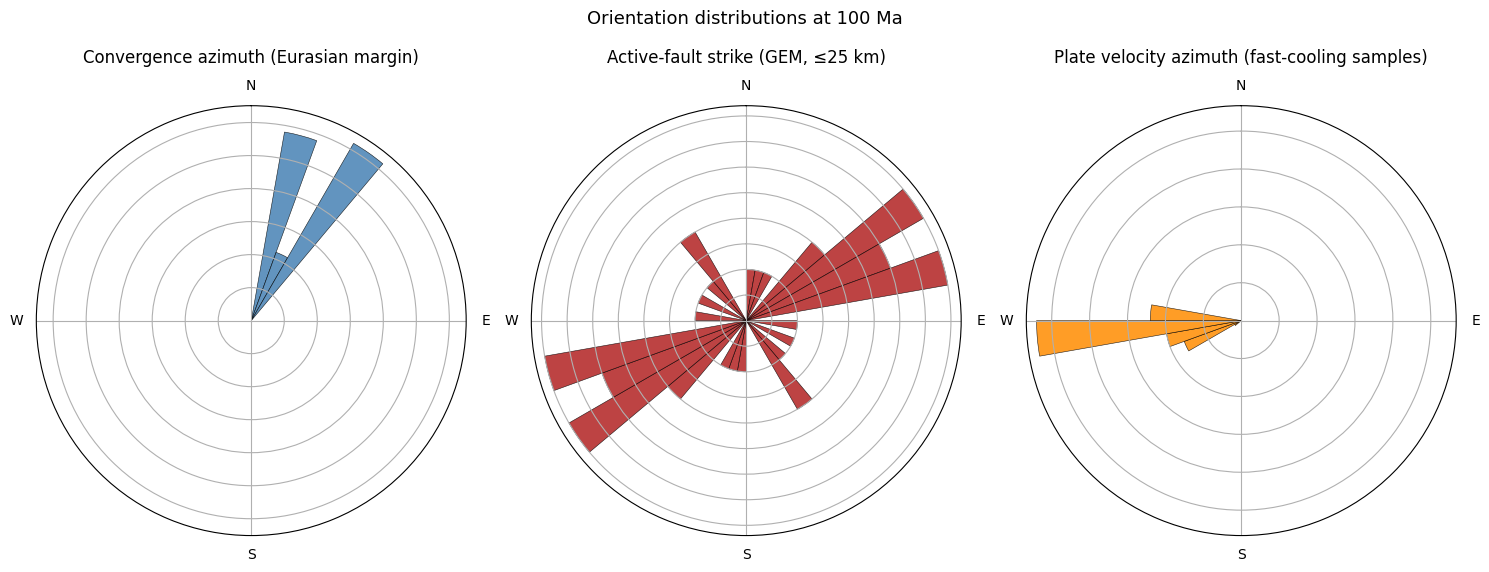

In [13]:
def rose_panel(ax, azimuths_deg, bin_deg=10, title="", bidirectional=False, color="steelblue"):
    """Polar histogram of azimuth values. North = up, east = right (compass)."""
    if len(azimuths_deg) == 0:
        ax.text(0.5, 0.5, "(no data)", transform=ax.transAxes, ha="center")
        ax.set_title(title)
        return
    az = np.asarray(azimuths_deg) % (180 if bidirectional else 360)
    bins = np.arange(0, (180 if bidirectional else 360) + bin_deg, bin_deg)
    counts, edges = np.histogram(az, bins=bins)
    if bidirectional:
        # Mirror the histogram so each bin shows on both sides.
        counts = np.concatenate([counts, counts])
        edges  = np.concatenate([edges[:-1], edges[:-1] + 180, [360]])
    theta = np.radians((edges[:-1] + edges[1:]) / 2)
    width = np.radians(bin_deg)
    ax.bar(theta, counts, width=width, bottom=0, color=color,
            edgecolor="black", linewidth=0.4, alpha=0.85)
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_xticks(np.radians([0, 90, 180, 270]))
    ax.set_xticklabels(["N", "E", "S", "W"])
    ax.set_yticklabels([])
    ax.set_title(title, pad=12)

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), subplot_kw={"projection": "polar"})
rose_panel(axes[0], conv_az,      title="Convergence azimuth (Eurasian margin)",        color="steelblue")
rose_panel(axes[1], fault_strike, title=f"Active-fault strike (GEM, ≤{FAULT_PROXIMITY_KM:.0f} km)",
           bidirectional=True, color="firebrick")
rose_panel(axes[2], plate_az,     title="Plate velocity azimuth (fast-cooling samples)", color="darkorange")
fig.suptitle(f"Orientation distributions at {RECONSTRUCTION_TIME:.0f} Ma", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()

## 8. §9 — Output a per-age kinematics_master row

Boone's `kinematics_master.xyz` is a 29-column unlabelled XYZ accumulated in
the script-03 time loop. Here we emit one parquet *per snapshot age* with
named columns — much easier to join with T50's `thermochron_master`.

In [14]:
row = {
    "age_Ma":                          float(RECONSTRUCTION_TIME),
    "n_samples":                       int(len(samples)),
    "n_fast_cooling":                  int(len(fast_samples)),
    "mean_cooling_rate":               float(samples["cooling_rate"].mean()),
    "std_cooling_rate":                float(samples["cooling_rate"].std()),
    "n_segments_eurasia":              int(len(kin_eu)),
    "mean_conv_rate_cm_yr":            float(kin_eu["conv_rate_cm_yr"].mean()),
    "std_conv_rate_cm_yr":             float(kin_eu["conv_rate_cm_yr"].std()),
    "mean_migr_rate_cm_yr":            float(kin_eu["migr_rate_cm_yr"].mean()),
    "std_migr_rate_cm_yr":             float(kin_eu["migr_rate_cm_yr"].std()),
    "mean_arc_azimuth_deg":            float(kin_eu["arc_normal_azimuth_deg"].mean()),
    "mean_conv_azimuth_deg":           float(conv_az.mean()),
    "n_gem_active":                    int(len(gem_active)),
    "n_gem_total":                     int(len(gem_faults)),
    "n_afead_active":                  int(len(afead_active)),
    "n_afead_total":                   int(len(afead_faults)),
    "mean_fault_strike_deg":           float(np.nanmean(fault_strike)) if len(fault_strike) else np.nan,
}
row_df = pd.DataFrame([row])
kin_path = KINEMATICS_MASTER_DIR / f"kinematics_master_{int(RECONSTRUCTION_TIME):03d}Ma.parquet"
row_df.to_parquet(kin_path)
print(f"  ✓ wrote {kin_path}")
row_df.T

  ✓ wrote data/thermochronology_central_asia/kinematics_master/kinematics_master_100Ma.parquet


,0
age_Ma,100.000000
n_samples,286.000000
n_fast_cooling,58.000000
mean_cooling_rate,0.689046
std_cooling_rate,0.844087
n_segments_eurasia,142.000000
mean_conv_rate_cm_yr,2.396207
std_conv_rate_cm_yr,1.648294
mean_migr_rate_cm_yr,1.035520
std_migr_rate_cm_yr,3.508584


## Extend this

- **Sweep through deep time.** Wrap §2–§9 in a loop over `range(0, 231, 5)` to build the full per-age `kinematics_master_*.parquet` cache. Concatenate the rows with `pd.concat([pd.read_parquet(p) for p in sorted(KINEMATICS_MASTER_DIR.glob('*.parquet'))])` and you have Boone et al. (2025)'s `kinematics_master.xyz` substrate — but as a labelled DataFrame.
- **Join with T50's thermochron_master.** Once both notebooks have populated their parquet caches, `pool.merge(kin_pool, on='age_Ma')` lets you correlate cooling rate against convergence rate / trench-migration rate / arc azimuth — extending T50's cross-variable analysis beyond mantle-flow forcings to the tectonic ones Boone et al. (2025) found *do* dominate.
- **Per-region splits.** The thermochronology compilation carries `Region` and `Sub-Region` IDs (Tian Shan / Altai / Siberian Plain etc.). Recompute the fault-proximity and kinematics summaries per region to see which subregion's exhumation tracks subduction kinematics most tightly.
- **Add the full rose-diagram set.** Boone's script generates 7 rose diagrams (plate vel, arc, conv, migr, USGS faults, AFEAD faults, plus a sample-density rose). The §7 cell above already shows the recipe — just call `rose_panel()` with `kin_eu['migr_azimuth_deg']`, AFEAD fault strikes, etc.
- **Replace the cookie-cut polygon.** Boone's published analysis uses one Eurasian-margin polygon, but the other two zips Sam shared (`Mongol_Okhotsk_Polygon`, `East_Asia_Arc_Polygons`) let you re-run the same kinematics + fault analysis for those margins as well. Just swap `EURASIA_POLYGON_DIR` in the config cell.
